Internal absorption
====================

In [1]:
import jetset
print('tested with',jetset.__version__)

tested with 1.4.0rc2


In this tutorial we show how to use the internal absorption for external radiative fields.

We first create a leptonic jet model with e EC components.

In [2]:
from jetset.jet_model import Jet
import numpy as np
from jetset.template_2Dmodel import EBLAbsorptionTemplate
import astropy.units as u

ebl_dominguez_2010=EBLAbsorptionTemplate.from_name('Dominguez_2010_v2011')
ebl_dominguez_lopez=EBLAbsorptionTemplate.from_name('Dominguez_2023')
ebl_finke=EBLAbsorptionTemplate.from_name('Finke_2010')
ebl_franceschini=EBLAbsorptionTemplate.from_name('Franceschini_2008')


jetset_model = Jet(name="compact_int_abs",emitters_distribution="bkn",beaming_expr='bulk_theta')
jetset_model.add_EC_component(EC_components_list=['EC_DT','EC_BLR','EC_Corona'],disk_type='BB')
jetset_model.make_conical_jet(theta_open=5,R=1E16)
jetset_model.set_EC_dependencies()

jetset_model.set_par('L_Disk',val=2E45)
jetset_model.set_par('gmax',val=5E5)
jetset_model.set_par('gmin',val=2.)
jetset_model.set_par('R_H',val=1E17)

jetset_model.set_par('p',val=1.5)
jetset_model.set_par('p_1',val=3.2)
jetset_model.set_par('B',val=1.5)
jetset_model.set_par('z_cosm',val=0.6)
jetset_model.set_par('BulkFactor',val=10)
jetset_model.set_par('theta',val=1)
jetset_model.set_par('gamma_break',val=5E2)
jetset_model.parameters.tau_DT.val=0.1
jetset_model.parameters.T_DT.val=1000
jetset_model.parameters.theta.freeze()
jetset_model.parameters.R_H.val=1E18
jetset_model.set_N_from_nuFnu(nu_obs=1E13,nuFnu_obs=1E-13)
jetset_model.set_external_field_transf('blob')



adding par: R_H to  R
adding par: theta_open to  R
==> par R is depending on ['R_H', 'theta_open'] according to expr:   R =
np.tan(np.radians(theta_open))*R_H
setting R_H to 1.1430052302761344e+17
adding par: L_Disk to  R_BLR_in
==> par R_BLR_in is depending on ['L_Disk'] according to expr:   R_BLR_in =
3E17*(L_Disk/1E46)**0.5
adding par: R_BLR_in to  R_BLR_out
==> par R_BLR_out is depending on ['R_BLR_in'] according to expr:   R_BLR_out =
R_BLR_in*1.1
adding par: L_Disk to  R_DT
==> par R_DT is depending on ['L_Disk'] according to expr:   R_DT =
2E19*(L_Disk/1E46)**0.5


In [3]:
jetset_model


--------------------------------------------------------------------------------
model description: 
--------------------------------------------------------------------------------
type: Jet
name: compact_int_abs  
geometry: spherical  

electrons distribution:
 type: bkn  
 gamma energy grid size:  201
 gmin grid : 2.000000e+00
 gmax grid : 5.000000e+05
 normalization:  True
 log-values:  False
 ratio of cold protons to relativistic electrons: 1.000000e+00

accretion disk:
 disk Type: BB
 L disk: 2.000000e+45 (erg/s)
 T disk: 1.000000e+05 (K)
 nu peak disk: 8.171810e+15 (Hz)
radiative fields:
 seed photons grid size:  100
 IC emission grid size:  100
 source emissivity lower bound :  1.000000e-120
 spectral components:
   name:Sum, state: on
   name:Sum, hidden: False
   name:Sync, state: self-abs
   name:Sync, hidden: False
   name:SSC, state: on
   name:SSC, hidden: False
   name:EC_DT, state: on
   name:EC_DT, hidden: False
   name:DT, state: on
   name:DT, hidden: False
   name:

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
compact_int_abs,"*R(D,theta_open)",region_size,cm,8.748866e+16,1.000000e+03,1.000000e+30,False,True
compact_int_abs,R_H(M),region_position,cm,1.000000e+18,0.000000e+00,--,False,False
compact_int_abs,B,magnetic_field,gauss,1.500000e+00,0.000000e+00,--,False,False
compact_int_abs,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
compact_int_abs,theta,jet-viewing-angle,deg,1.000000e+00,0.000000e+00,9.000000e+01,False,True
compact_int_abs,BulkFactor,jet-bulk-factor,lorentz-factor*,1.000000e+01,1.000000e+00,1.000000e+05,False,False
compact_int_abs,z_cosm,redshift,,6.000000e-01,0.000000e+00,--,False,False
compact_int_abs,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
compact_int_abs,gmax,high-energy-cut-off,lorentz-factor*,5.000000e+05,1.000000e+00,1.000000e+15,False,False
compact_int_abs,N,emitters_density,1 / cm3,6.143592e-02,0.000000e+00,--,False,False


--------------------------------------------------------------------------------


None

Now we can enable the internal absorption for the BLR and DT fields, and evaluate the model with internal absorption applied

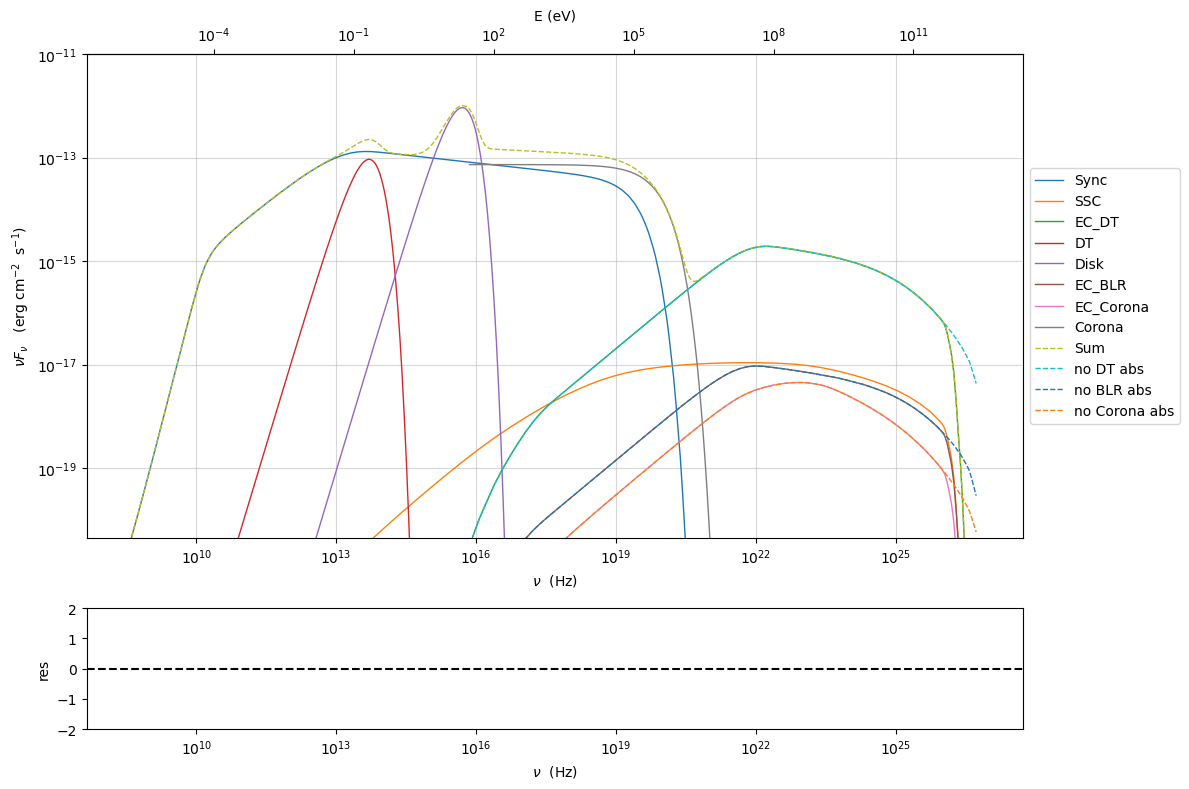

In [4]:

jetset_model.enable_internal_absorption('DT')
jetset_model.enable_internal_absorption('BLR')
jetset_model.enable_internal_absorption('Corona')

jetset_model.eval()
p=jetset_model.plot_model()

jetset_model.remove_internal_absorption('DT')
jetset_model.remove_internal_absorption('BLR')
jetset_model.remove_internal_absorption('Corona')

jetset_model.eval()
jetset_model.plot_model(plot_obj=p,comp='EC_DT',label='no DT abs',line_style='--')
jetset_model.plot_model(plot_obj=p,comp='EC_BLR',label='no BLR abs',line_style='--')
jetset_model.plot_model(plot_obj=p,comp='EC_Corona',label='no Corona abs',line_style='--')



In [6]:

jetset_model.enable_internal_absorption('DT')
jetset_model.enable_internal_absorption('BLR')
jetset_model.enable_internal_absorption('Corona')


This model can be used now for model fitting.

In [7]:
jetset_model.show_internal_absorption_components()

internal absorption  for component: DT
('N_hard', 50)
('N_soft', 50)
('N_theta', 50)
('N_R_H', 50)
('nu_min', 1e+20)
('comp', 'DT')
('use_R_H_profile_extrapolation', False)
('use_sigma_gamma_gamma_fast', False)

internal absorption  for component: BLR
('N_hard', 50)
('N_soft', 50)
('N_theta', 50)
('N_R_H', 50)
('nu_min', 1e+20)
('comp', 'BLR')
('use_R_H_profile_extrapolation', False)
('use_sigma_gamma_gamma_fast', False)

internal absorption  for component: Corona
('N_hard', 50)
('N_soft', 50)
('N_theta', 50)
('N_R_H', 50)
('nu_min', 1e+20)
('comp', 'Corona')
('use_R_H_profile_extrapolation', False)
('use_sigma_gamma_gamma_fast', False)



Please, notice that the internal absorption will slow down a bit the computation. Let's quantify the effect for a single component. 
First we remove the BLR and Corona absorption, to assess the impact of a single component.

In [8]:
jetset_model.remove_internal_absorption('BLR')
jetset_model.remove_internal_absorption('Corona')

jetset_model.show_internal_absorption_components()

internal absorption  for component: DT
('N_hard', 50)
('N_soft', 50)
('N_theta', 50)
('N_R_H', 50)
('nu_min', 1e+20)
('comp', 'DT')
('use_R_H_profile_extrapolation', False)
('use_sigma_gamma_gamma_fast', False)



In [9]:
%timeit jetset_model.eval()

13.1 ms ± 47.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [10]:
jetset_model.remove_internal_absorption('DT')


In [11]:
%timeit jetset_model.eval()
jetset_model.show_internal_absorption_components()

5.53 ms ± 49.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
internal absorption not enabled in this jet model


The increase in computational time, for component, compared to an EC model without absorption, is of a factor of ~ 2.5 


By setting `use_R_H_profile_extrapolation=True`, we can speed up the process

In [13]:
jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=False)


In [14]:
%timeit _=jetset_model.eval_internal_absorption(comp='DT', peak=False)

10.6 ms ± 23.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=True)


In [16]:
%timeit _=jetset_model.eval_internal_absorption(comp='DT', peak=False)

5.33 ms ± 21.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


By setting `use_sigma_gamma_gamma_fast=True`, we can further speed up the process, by using interpolated cross section.

In [17]:
jetset_model.enable_internal_absorption('DT',use_sigma_gamma_gamma_fast=True,use_R_H_profile_extrapolation=True)


In [18]:
%timeit _=jetset_model.eval_internal_absorption(comp='DT', peak=False)

3.69 ms ± 188 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [19]:
jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=True)

%timeit jetset_model.eval()

6.33 ms ± 79.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


The increase in computational time is lower now, down to a factor of ~1.2 per absorption component. 



In the following some plots showing the accuracy effect when using `use_R_H_profile_extrapolation=True`, so you can choose accordingly, if whether to use the approximation or not.

In [ ]:
jetset_model.remove_internal_absorption('BLR')
jetset_model.remove_internal_absorption('DT')
jetset_model.remove_internal_absorption('Corona')

jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=True)
jetset_model.enable_internal_absorption('BLR',use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=True)
jetset_model.enable_internal_absorption('Corona',use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=True)

%timeit jetset_model.eval()

36.4 ms ± 77 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


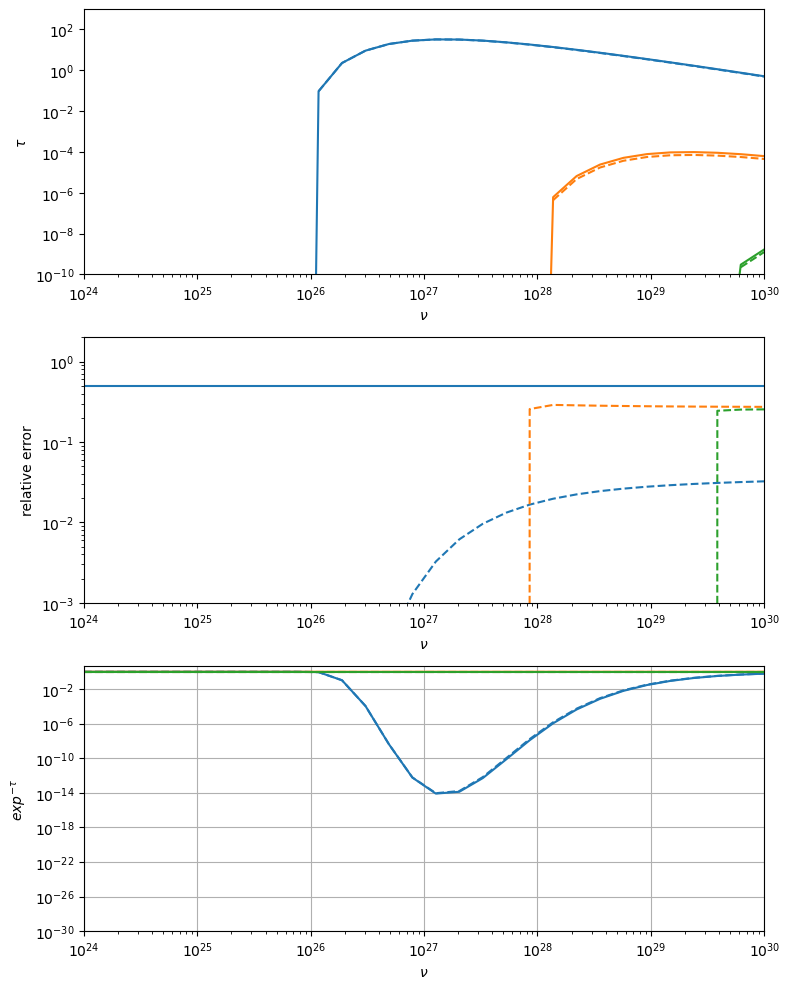

In [18]:
from matplotlib import pylab as plt
jetset_model.parameters.tau_BLR.val=0.1
#jetset_model.parameters.T_DT.val=1000
fig,axs=plt.subplots(3,1,figsize=(8,10))
nu_tau=np.logspace(24,30,30)
R_DT=jetset_model.parameters.R_DT.val
colors = ['C0','C1','C2']
comp='DT'
for ID,f in enumerate([0.1,5,30]):
    jetset_model.parameters.R_H.val=R_DT*f
    jetset_model.eval()
    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
    y,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    
    x=x*u.Hz
 
    axs[0].loglog( x,y,c=colors[ID])
    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=False)
    y1,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    x=x*u.Hz
    msk=y>1E-10
    axs[0].loglog( x[msk],y1[msk],'--',c=colors[ID])

    axs[1].loglog( x,np.fabs(y1-y)/y,'--',c=colors[ID])

    axs[2].loglog( x,np.exp(-y),'-',c=colors[ID])
    axs[2].loglog( x,np.exp(-y1),'--',c=colors[ID])
axs[0].set_xlim(1E24,1E30)

axs[1].set_xlim(1E24,1E30)
axs[2].set_xlim(1E24,1E30)


axs[1].axhline(.5)

axs[0].set_ylim(1E-10,1E3)
axs[1].set_ylim(1E-3,2)
axs[2].set_ylim(1E-30,)
axs[0].set_xlabel(r'$\nu$')
axs[1].set_xlabel(r'$\nu$')
axs[2].set_xlabel(r'$\nu$')

axs[0].set_ylabel(r'$\tau$')
axs[1].set_ylabel(r'relative error')
axs[2].set_ylabel(r'$exp^{-\tau}$')
plt.tight_layout()
plt.grid()

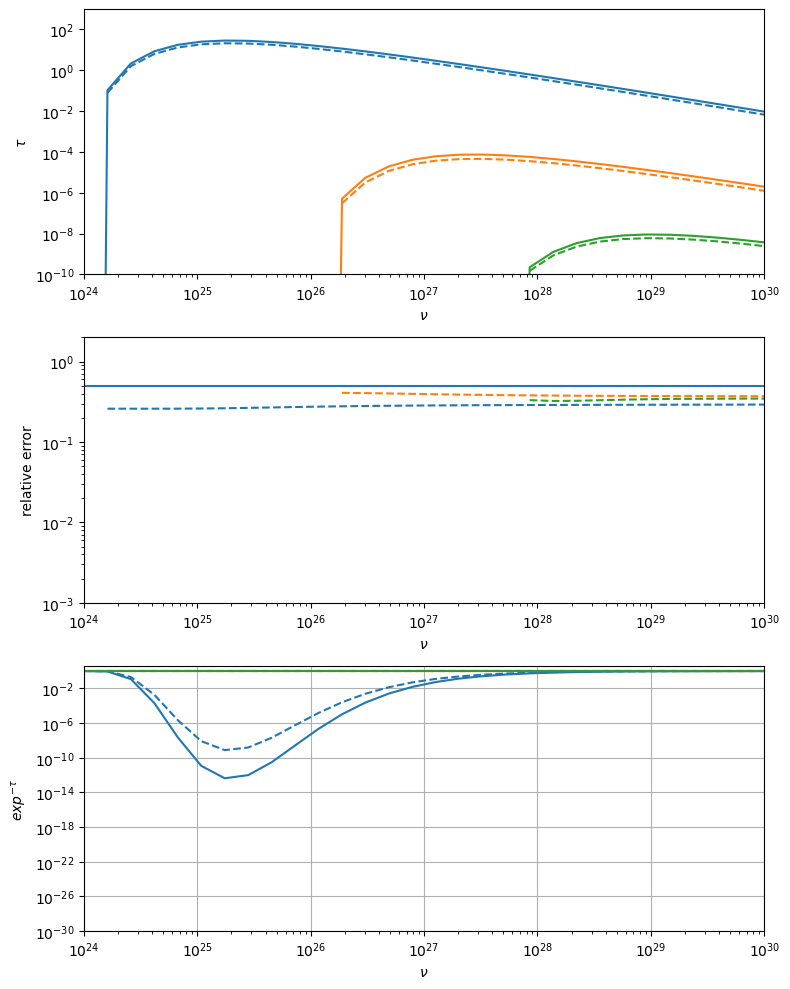

In [19]:
from matplotlib import pylab as plt
jetset_model.parameters.tau_BLR.val=0.1
#jetset_model.parameters.T_DT.val=1000
fig,axs=plt.subplots(3,1,figsize=(8,10))
nu_tau=np.logspace(24,30,30)
R_BLR=jetset_model.parameters.R_BLR_out.val
colors = ['C0','C1','C2']
comp='BLR'
for ID,f in enumerate([0.1,5,30]):
    jetset_model.parameters.R_H.val=R_BLR*f
    jetset_model.eval()
    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
    y,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)

    x=x*u.Hz
 
    axs[0].loglog( x,y,c=colors[ID])

    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=False)
    y1,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    x=x*u.Hz
    msk=y>1E-10
    axs[0].loglog( x[msk],y1[msk],'--',c=colors[ID])

    axs[1].loglog( x[msk],np.fabs(y1[msk]-y[msk])/y[msk],'--',c=colors[ID])

    axs[2].loglog( x,np.exp(-y),'-',c=colors[ID])
    axs[2].loglog( x,np.exp(-y1),'--',c=colors[ID])
axs[0].set_xlim(1E24,1E30)

axs[1].set_xlim(1E24,1E30)
axs[2].set_xlim(1E24,1E30)


axs[1].axhline(.5)

axs[0].set_ylim(1E-10,1E3)
axs[1].set_ylim(1E-3,2)
axs[2].set_ylim(1E-30,)
axs[0].set_xlabel(r'$\nu$')
axs[1].set_xlabel(r'$\nu$')
axs[2].set_xlabel(r'$\nu$')

axs[0].set_ylabel(r'$\tau$')
axs[1].set_ylabel(r'relative error')
axs[2].set_ylabel(r'$exp^{-\tau}$')
plt.tight_layout()
plt.grid()

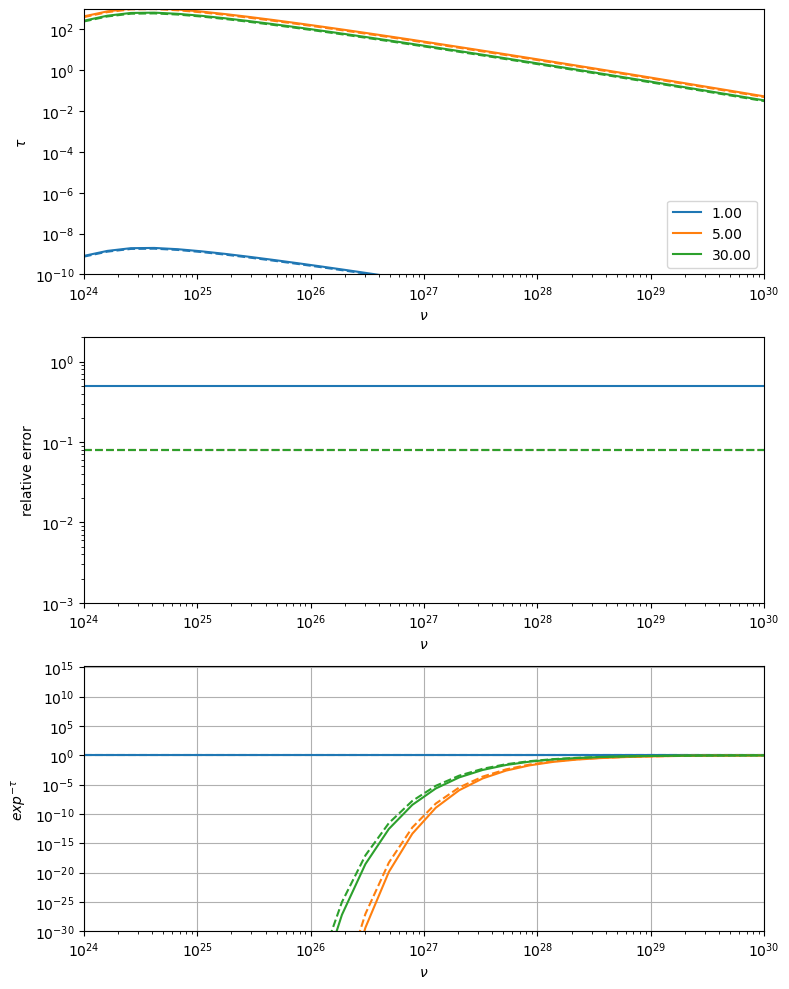

In [20]:
from matplotlib import pylab as plt
#jetset_model.parameters.T_DT.val=1000
fig,axs=plt.subplots(3,1,figsize=(8,10))
nu_tau=np.logspace(24,30,30)
jetset_model.parameters.R_H_Corona.val=1E13
colors = ['C0','C1','C2']
comp='Corona'
nu_tau=np.logspace(24,30,30)
R_H_corona=jetset_model.parameters.R_H_Corona.val
for ID,f in enumerate([1,5,30]):
    jetset_model.parameters.R_H.val=R_H_corona*f
    jetset_model.eval()
    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
    y,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)

    x=x*u.Hz
 
    axs[0].loglog( x,y,c=colors[ID],label='%2.2f'%f)

    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=False)
    y1,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)

    x=x*u.Hz
 
    axs[0].loglog( x,y1,'--',c=colors[ID])

    axs[1].loglog( x,np.fabs(y1-y)/y,'--',c=colors[ID])

    axs[2].loglog( x,np.exp(-y),'-',c=colors[ID])
    axs[2].loglog( x,np.exp(-y1),'--',c=colors[ID])
axs[0].set_xlim(1E24,1E30)
axs[0].legend()
axs[1].set_xlim(1E24,1E30)
axs[2].set_xlim(1E24,1E30)


axs[1].axhline(.5)

axs[0].set_ylim(1E-10,1E3)
axs[1].set_ylim(1E-3,2)
axs[2].set_ylim(1E-30,)
axs[0].set_xlabel(r'$\nu$')
axs[1].set_xlabel(r'$\nu$')
axs[2].set_xlabel(r'$\nu$')


axs[0].set_ylabel(r'$\tau$')
axs[1].set_ylabel(r'relative error')
axs[2].set_ylabel(r'$exp^{-\tau}$')

plt.tight_layout()
plt.grid()